In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["JAX_ENABLE_X64"] = "true" # TODO

import dataclasses
import json

import numpy as onp
import jax
import matplotlib.pyplot as plt

from msmjax.calculators import (
    MSMParams,
    set_up_msm_params_static_cell,
    create_msm,
)
from msmjax.utils.convenience import (
    suggest_msm_params,
    set_up_kernels_grids_and_stencils,
)
from msmjax.utils.misc import (
    path_input_structures,
)

# Set up

In [2]:
PBC = (False, False, False)
LEVEL_ONE_GRIDSPACING = 1.0
LEVEL_ZERO_CUTOFF = 3.0

In [3]:
structures = onp.load(path_input_structures / "structures_10000.npz")

In [4]:
(n_particles, n_dim) = structures["positions"][0].shape
cell = structures["cells"][0]
pos = structures["positions"][0]
chg = structures["charges"][0]
cell = cell.astype(onp.float64)
pos = pos.astype(onp.float64)
chg = chg.astype(onp.float64)

In [5]:
suggested_params = suggest_msm_params(
    box_lengths=onp.diag(cell),
    pbc=PBC,
    n_particles=n_particles,
    level_one_gridspacing=LEVEL_ONE_GRIDSPACING,
    level_zero_cutoff=LEVEL_ZERO_CUTOFF,
)
suggested_params

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")



{'level_one_gridspacing': [1.0, 1.0, 1.0],
 'level_zero_cutoff': 3.0,
 'p': 4,
 'mu': 14,
 'n_levels': 5}

In [6]:
max_level_split = suggested_params["n_levels"]
if not onp.any(PBC):
    max_level_eval = max_level_split
elif onp.all(PBC):
    max_level_eval = max_level_split - 1
else:
    raise ValueError("Mixed BCs currently not handled.")

convolution_methods = [None] + ["scipy-fft"] * max_level_eval
params_dataclass = MSMParams(
    p=suggested_params["p"],
    mu=suggested_params["mu"],
    r_cut_0=suggested_params["level_zero_cutoff"],
    h_1=suggested_params["level_one_gridspacing"],
    max_splitting_level=max_level_split,
    max_grid_level=max_level_eval,
    cell=cell,
    cell_mode="ortho",
    pbc=PBC,
    supercell_diag=None,
    use_neighborlist=False,
    convolution_methods=convolution_methods,  # TODO: sequence
    grids_defined_on_unitcube=False,  # TODO
)

# Generate reference results

In [7]:
import sys

sys.path.append("/home/florian/PhD/work/code/personal_scripts/")

from matplotlib_snippets.utils import plot_parity_line

from msmjax.core.shortrange import make_eval_pair_pot


def calc_energy_ref_nonperiodic(positions, charges):
    n_dim = positions.shape[1]
    compute_pair_term = make_eval_pair_pot(
        kernel_fn=lambda x: 1.0 / x, pbc=(False,) * n_dim
    )
    return compute_pair_term(positions, charges)


def calc_forces_ref_nonperiodic(positions, charges):
    return -jax.grad(calc_energy_ref_nonperiodic, argnums=0)(
        positions, charges
    )


calc_energy_ref_nonperiodic = jax.jit(calc_energy_ref_nonperiodic)
calc_forces_ref_nonperiodic = jax.jit(calc_forces_ref_nonperiodic)

In [8]:
N_PARTICLES_NONPERIODIC = 10000
N_PARTICLES_PERIODIC = 500

onp.load(path_input_structures / f"structures_{N_PARTICLES_NONPERIODIC}.npz")[
    "cells"
][0]

array([[21.544348,  0.      ,  0.      ],
       [ 0.      , 21.544348,  0.      ],
       [ 0.      ,  0.      , 21.544348]], dtype=float32)

# Calculate

In [9]:
(
    calc_energy,
    calc_forces,
    calc_energy_and_forces,
    calc_charge_gradient,
) = create_msm(params_dataclass)

calc_energy = jax.jit(calc_energy)
calc_forces = jax.jit(calc_forces)

In [10]:
# e_msm = calc_energy(pos, chg, neighborlist=jnp.array([1., 2., 3.]))
e_msm = calc_energy(pos, chg)

e_msm

Array(-40.38278237, dtype=float64)

In [11]:
# f_msm = calc_forces(pos, chg, neighborlist=jnp.array([1.0, 2.0, 3.0]))
f_msm = calc_forces(pos, chg)

f_msm

Array([[ 0.73853043, -0.24289055, -0.35225429],
       [-1.23556034, -0.74068227, -0.23327418],
       [-1.12392592, -2.55162579, -0.38015646],
       ...,
       [-0.30609247, -0.78932256, -0.24524063],
       [ 0.91776981,  1.79724765, -0.05913628],
       [ 1.27772065, -0.64229829, -1.76050789]], dtype=float64)

In [12]:
e_ref = calc_energy_ref_nonperiodic(pos, chg)
f_ref = calc_forces_ref_nonperiodic(pos, chg)

e_ref

Array(-37.43308722, dtype=float64)

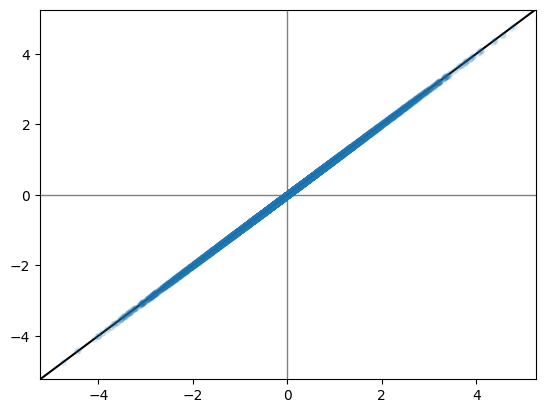

In [13]:
fig, ax = plt.subplots()
ax.scatter(f_ref, f_msm, alpha=0.1, s=15)
ax.axhline(0, color="gray", linewidth=1, zorder=-1)
ax.axvline(0, color="gray", linewidth=1, zorder=-1)
plot_parity_line(ax, color="black", zorder=-1)
plt.show()

# Serialization

In [14]:
# with open("out/params.json", "w") as f:
#     json.dump(
#         dataclasses.asdict(params_dataclass),
#         f,
#         cls=CustomJSONEncoder,
#         indent=2,
#     )

In [15]:
# with open("out/params.json", "r") as f:
#     loaded = json.load(f, cls=CustomJSONDecoder)
# loaded_dataclass = MSMParams(**loaded)

In [16]:
def test_params_equal(first: MSMParams, second: MSMParams):
    if not type(first) is type(second):
        return False
    field_names_first = [field.name for field in dataclasses.fields(first)]
    field_names_second = [field.name for field in dataclasses.fields(second)]
    if not sorted(field_names_first) == sorted(field_names_second):
        return False

    for field_name in field_names_first:
        val_1 = getattr(first, field_name)
        val_2 = getattr(second, field_name)
        if isinstance(val_1, onp.ndarray) and isinstance(val_2, onp.ndarray):
            # TODO: this is not going to work for nested data (like a list of arrays)
            if not onp.array_equal(val_1, val_2):
                return False
        else:
            if val_1 != val_2:
                return False

    return True

In [17]:
# test_params_equal(params_dataclass, loaded_dataclass)

In [18]:
path_jsonfile = "out/params.json"

params_dataclass.save_json(path_jsonfile, indent=2)
assert test_params_equal(params_dataclass, MSMParams.load_json(path_jsonfile))

## inf values

In [28]:
my_cool_cutoff_list = [None, 1.5, 3.0, 6.0, onp.inf]
my_cool_cutoff_list

[None, 1.5, 3.0, 6.0, inf]

In [40]:
with open("out/cutoffs.json", "w") as f:
    json.dump(my_cool_cutoff_list, f)
print(my_cool_cutoff_list)

with open("out/cutoffs.json", "r") as f:
    loaded = json.load(f)
print(loaded)

[None, 1.5, 3.0, 6.0, inf]
[None, 1.5, 3.0, 6.0, inf]


In [41]:
type(loaded[-1])

float

In [42]:
type(my_cool_cutoff_list[-1])

float

In [44]:
my_cool_cutoff_list[-1] == loaded[-1]

True

# Grid setup

In [2]:
from msmjax.bspline.coefficients import compute_J_zeroplus
from msmjax.bspline.gridops import (
    BSplineInterpolationAxis,
    BSplineInterpolationGrid,
    set_up_grid_axis,
    set_up_grids_all_levels,
    create_restriction_operator_1d,
    create_restriction_operator,
    create_prolongation_operator_1d,
    create_prolongation_operator,
    arbitrary_dim_outer,
)
from msmjax.bspline.gridops import (
    _make_restrict_1d,
    _make_prolongate_1d,
    make_basis_evaluation_fn,
)

In [3]:
structs_for_clean = onp.load(
    "../tests/data/nonperiodic_ortho-different-sidelengths.npz"
)

In [6]:
P = 4
box_lengths = onp.diag(structs_for_clean["cell"])
J_zeroplus = compute_J_zeroplus(P)

# pbc_for_clean = (False, False, False)
# spacings = onp.array([1.0, 1.1, 1.25])

pbc_for_clean = (True, True, True)
spacings = box_lengths / 8

grids = set_up_grids_all_levels(
    box_lengths=box_lengths,
    level_one_spacings=spacings,
    pbcs=pbc_for_clean,
    n_levels=7,
    p=P,
    J_zeroplus=J_zeroplus,
)

In [7]:
[None if g is None else g.shape for g in grids]

[None,
 (8, 8, 8),
 (4, 4, 4),
 (2, 2, 2),
 (1, 1, 1),
 (1, 1, 1),
 (1, 1, 1),
 (1, 1, 1)]

## Cleaner restriction

In [9]:
axis_source_fine = grids[1].axes[0]
axis_target_coarse = grids[2].axes[0]

restrict_1d = jax.jit(
    create_restriction_operator_1d(axis_source_fine, axis_target_coarse)
)
clean_restrict_1d = jax.jit(
    # make_clean_restrict_1d(axis_source_fine, axis_target_coarse)
    _make_restrict_1d(
        n_points_in=axis_source_fine.n_total,
        n_points_out=axis_target_coarse.n_total,
        p=P,
        is_periodic=pbc_for_clean[0],
    )
)

n_points_fine = axis_source_fine.n_total
n_points_coarse = axis_target_coarse.n_total

rng = onp.random.default_rng(2479)
gridcharge_fine = rng.uniform(-1.0, 1.0, size=n_points_fine)
gridcharge_fine -= gridcharge_fine.mean()
gridcharge_fine = jax.device_put(gridcharge_fine)

In [10]:
assert onp.allclose(
    restrict_1d(gridcharge_fine),
    clean_restrict_1d(gridcharge_fine),
    atol=1.0e-6,
)

%timeit restrict_1d(gridcharge_fine).block_until_ready()
%timeit clean_restrict_1d(gridcharge_fine).block_until_ready()

45.4 μs ± 3.84 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
41.7 μs ± 3.86 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Cleaner prolongation

In [11]:
axis_source_coarse = grids[2].axes[0]
axis_target_fine = grids[1].axes[0]

prolongate_1d = jax.jit(
    create_prolongation_operator_1d(axis_source_coarse, axis_target_fine)
)
clean_prolongate_1d = jax.jit(
    # make_clean_prolongate_1d(axis_source_coarse, axis_target_fine)
    _make_prolongate_1d(
        n_points_in=axis_source_coarse.n_total,
        n_points_out=axis_target_fine.n_total,
        p=P,
        is_periodic=pbc_for_clean[0],
    )
)

n_points_coarse = axis_source_coarse.n_total
n_points_fine = axis_target_fine.n_total

rng = onp.random.default_rng(2479)
gridpotential_coarse = rng.uniform(-1.0, 1.0, size=n_points_coarse)
gridpotential_coarse -= gridpotential_coarse.mean()
gridpotential_coarse = jax.device_put(gridpotential_coarse)

In [12]:
assert onp.allclose(
    prolongate_1d(gridpotential_coarse),
    clean_prolongate_1d(gridpotential_coarse),
    atol=1.0e-6,
)

%timeit prolongate_1d(gridpotential_coarse).block_until_ready()
%timeit clean_prolongate_1d(gridpotential_coarse).block_until_ready()

46.9 μs ± 3.97 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
45.8 μs ± 2.86 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Cleaner basis evaluation

In [13]:
positions = structs_for_clean["positions"]

In [14]:
old_eval_basis = jax.jit(grids[1].evaluate_bspline_basis_one_particle)
splinevals_old, inds_old = old_eval_basis(positions[0])

clean_eval_basis = jax.jit(
    # make_clean_eval_basis(grid_shape=grids[1].shape, p=P, pbc=pbc_for_clean),
    make_basis_evaluation_fn(
        grid_shape=grids[1].shape, p=P, pbc=pbc_for_clean
    ),
)
splinevals_clean, inds_clean = clean_eval_basis(positions[0], spacings)

assert onp.allclose(splinevals_clean, splinevals_old, atol=1.0e-6)
assert onp.array_equal(inds_clean, inds_old)

a = jax.device_put(positions[0])
b = jax.device_put(spacings)

%timeit jax.tree.flatten(old_eval_basis(a))[0][0].block_until_ready()
%timeit jax.tree.flatten(clean_eval_basis(a,b))[0][0].block_until_ready()

121 μs ± 17.5 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
75.5 μs ± 2.52 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [15]:
old_eval_multiparticle = jax.jit(grids[1].evaluate_bspline_basis_multiparticle)
old_eval_grad_multiparticle = jax.jit(
    grids[1].evaluate_bspline_basis_gradient_multiparticle
)


@jax.jit
def clean_eval_multiparticle(positions, spacings):
    return jax.vmap(clean_eval_basis, in_axes=(0, None))(positions, spacings)


@jax.jit
def clean_eval_grad_multiparticle(positions, spacings):
    return jax.vmap(
        jax.jacfwd(clean_eval_basis, has_aux=True), in_axes=(0, None)
    )(positions, spacings)


a = jax.device_put(positions)
b = jax.device_put(spacings)

print("old_eval_multiparticle:")
fn = old_eval_multiparticle
jax.tree.flatten(fn(a))[0][0].block_until_ready()
%timeit jax.tree.flatten(fn(a))[0][0].block_until_ready()

print("clean_eval_multiparticle:")
fn = clean_eval_multiparticle
jax.tree.flatten(fn(a, b))[0][0].block_until_ready()
%timeit jax.tree.flatten(fn(a, b))[0][0].block_until_ready()

print()

print("old_eval_grad_multiparticle:")
fn = old_eval_grad_multiparticle
jax.tree.flatten(fn(a))[0][0].block_until_ready()
%timeit jax.tree.flatten(fn(a))[0][0].block_until_ready()

print("clean_eval_grad_multiparticle:")
fn = clean_eval_grad_multiparticle
jax.tree.flatten(fn(a, b))[0][0].block_until_ready()
%timeit jax.tree.flatten(fn(a, b))[0][0].block_until_ready()

old_eval_multiparticle:
247 μs ± 10.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
clean_eval_multiparticle:
286 μs ± 4.98 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

old_eval_grad_multiparticle:
1.15 ms ± 21.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
clean_eval_grad_multiparticle:
1.24 ms ± 12.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
vals_clean, inds_clean = clean_eval_multiparticle(positions, spacings)
vals_old, inds_old = old_eval_multiparticle(positions)
assert onp.allclose(
    vals_clean,
    vals_old,
    atol=1.0e-6,
)
assert onp.array_equal(inds_clean, inds_old)

grads_clean, inds_clean = clean_eval_grad_multiparticle(positions, spacings)
grads_old, inds_old = old_eval_grad_multiparticle(positions)
assert onp.allclose(
    grads_clean,
    grads_old,
    atol=1.0e-6,
)
assert onp.array_equal(inds_clean, inds_old)

# Kernel stencil construction

In [46]:
# sizes_from_center = (6, 6, 6)
# hs = onp.array([1.0, 1.0, 1.0])
sizes_from_center = (2, 2)
hs = onp.array([1.5, 1.5])

In [80]:
angle = onp.pi / 3
gridcell = onp.array(
    [[1.0, 0.0], [onp.cos(angle), onp.sin(angle)]]
) @ onp.diag(hs)
gridcell

array([[1.5       , 0.        ],
       [0.75      , 1.29903811]])

In [47]:
indices_per_axis = [onp.arange(-s, s + 1) for s in sizes_from_center]
indices_per_axis

[array([-2, -1,  0,  1,  2]), array([-2, -1,  0,  1,  2])]

In [48]:
# set_up_kernels_grids_and_stencils()

In [49]:
indices = onp.stack(onp.meshgrid(*indices_per_axis, indexing="ij"), axis=-1)

In [50]:
indices.shape

(5, 5, 2)

In [81]:
points = indices * hs
points_tilted = indices @ gridcell

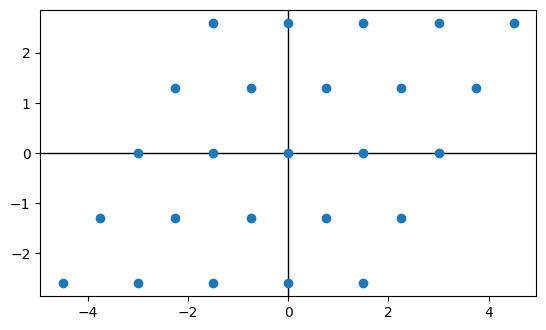

In [82]:
fig, ax = plt.subplots()
ax.axhline(0, color="black", linewidth=1, zorder=-10)
ax.axvline(0, color="black", linewidth=1, zorder=-10)
ax.set_aspect("equal")
# ax.scatter(indices[..., 0], indices[..., 1])
# ax.scatter(points[..., 0], points[..., 1])
ax.scatter(points_tilted[..., 0], points_tilted[..., 1])
plt.show()

In [145]:
# from msmjax.utils import _sqrt
#
#
# def get_distances(sizes_from_center, spacing_or_gridcell):
#     # TODO: jnp?
#     indices_per_axis = [onp.arange(-s, s + 1) for s in sizes_from_center]
#     indices = onp.stack(
#         onp.meshgrid(*indices_per_axis, indexing="ij"), axis=-1
#     )
#     if onp.ndim(spacing_or_gridcell) < 2:
#         points = indices * spacing_or_gridcell
#     else:
#         points = indices @ spacing_or_gridcell
#     return _sqrt((points * points).sum(axis=-1))


# def dists_from_inds(indices, spacings_or_gridcell):
#     if onp.ndim(spacings_or_gridcell) < 2:
#         points = indices * spacings_or_gridcell
#     else:
#         points = indices @ spacings_or_gridcell
#     return _sqrt((points * points).sum(axis=-1))

In [144]:
from typing import Callable, Literal
from jax.typing import ArrayLike
from jax import Array

from msmjax.kernels import _compute_kernel_stencil

# TODO: define elsewhere
CellMode = Literal["ortho", "general"]

from msmjax.utils.misc import _sqrt


def get_distances(sizes_from_center, spacing_or_gridcell):
    # TODO: jnp?
    indices_per_axis = [onp.arange(-s, s + 1) for s in sizes_from_center]
    indices = onp.stack(
        onp.meshgrid(*indices_per_axis, indexing="ij"), axis=-1
    )
    if onp.ndim(spacing_or_gridcell) < 2:
        points = indices * spacing_or_gridcell
    else:
        points = indices @ spacing_or_gridcell
    return _sqrt((points * points).sum(axis=-1))


def construct_stencils(
    omega: ArrayLike,
    n_levels_intermediate: int,
    include_toplevel: bool,
    k_lvl_1: Callable[[ArrayLike], Array] = None,
    sizes_intermediate: tuple[int, ...] = None,
    spacings_or_gridcell_lvl_1: ArrayLike = None,
    k_toplevel: Callable[[ArrayLike], Array] = None,
    sizes_toplevel: tuple[int, ...] = None,
) -> list[Array]:
    # Placeholder for level zero (l = 0), at which there is no grid:
    stencils = [None]

    if n_levels_intermediate < 0:
        raise ValueError("n_levels_intermediate must be >= 0")
    if n_levels_intermediate == 0 and not include_toplevel:
        raise ValueError(
            "n_levels_intermediate = 0 and include_toplevel = False "
            "at the same is not allowed (this would mean that "
            "there isn't a single grid level)."
        )
    if n_levels_intermediate > 0 and None in [
        k_lvl_1,
        sizes_intermediate,
        spacings_or_gridcell_lvl_1,
    ]:
        raise ValueError(
            "k_lvl_1, sizes_intermediate, spacings_or_gridcell_lvl_1 "
            "are required when n_levels_intermediate > 0."
        )
    if include_toplevel and None in [k_toplevel, sizes_toplevel]:
        raise ValueError(
            "k_toplevel, sizes_toplevel "
            "are required when include_toplevel = True."
        )

    # Intermediate levels (l = 1 ... L - 1):
    if n_levels_intermediate > 0:
        distances_lvl_1 = get_distances(
            sizes_intermediate, spacings_or_gridcell_lvl_1
        )
        kernel_values_at_gridpoints = k_lvl_1(distances_lvl_1)
        stencils.append(
            _compute_kernel_stencil(kernel_values_at_gridpoints, omega)
        )
        for lvl in range(n_levels_intermediate - 1):
            stencils.append(0.5 * stencils[-1])

    # Top level containing long-range tail (l = L), if included
    if include_toplevel:
        # TODO: sizes_toplevel must be larger than the top-level grid to avoid information loss
        #  during stencil computation but can be trimmed down to (2 * grid_shape - 1) later.
        #  -> Where and when should this happen?
        max_grid_level = n_levels_intermediate + 1
        distances_toplevel = get_distances(
            sizes_toplevel,
            2 ** (max_grid_level - 1) * spacings_or_gridcell_lvl_1,
        )
        kernel_values_at_gridpoints = k_toplevel(distances_toplevel)
        stencils.append(
            _compute_kernel_stencil(kernel_values_at_gridpoints, omega)
        )

    return stencils

In [ ]:
set_up_kernels_grids_and_stencils(box)

In [146]:
box_lengths

array([37.77557058, 22.8942852 , 10.30242834])

# New determination of number of levels

In [2]:
from matscipy.neighbours import neighbour_list

from msmjax.utils.convenience import suggest_max_gridlevel_nonPBC
from external_fns import suggest_max_grid_level_nonperiodic

In [3]:
def remove_duplicates_from_neighborlist(neighborlist):
    without_duplicates = onp.unique(
        onp.sort(onp.column_stack([neighborlist[0], neighborlist[1]]), axis=1),
        axis=0,
    )
    without_duplicates = (without_duplicates[:, 0], without_duplicates[:, 1])
    return without_duplicates

In [4]:
structures = onp.load(path_input_structures / "structures_1000.npz")

pos = structures["positions"][0]
chg = structures["charges"][0]
cll = structures["cells"][0]

(n_particles, n_dim) = pos.shape
side_lengths = onp.diag(cll)

In [5]:
side_lengths

array([10., 10., 10.], dtype=float32)

In [7]:
LEVEL_ONE_SPACINGS = onp.array([1.0, 1.0, 1.0])
LEVEL_ZERO_CUTOFF = 3.0
PBC = (False, False, False)
P = 4

In [8]:
suggest_max_gridlevel_nonPBC(
    max_pos=side_lengths,
    min_pos=onp.zeros_like(side_lengths),
    nb_particles=n_particles,
    level_one_gridspacing=LEVEL_ONE_SPACINGS,
    level_zero_cutoff=LEVEL_ZERO_CUTOFF,
    p=P,
)

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")



4

In [9]:
max_level_suggested = suggest_max_grid_level_nonperiodic(
    side_lengths=side_lengths,
    n_particles=n_particles,
    level_one_spacings=LEVEL_ONE_SPACINGS,
    level_zero_cutoff=LEVEL_ZERO_CUTOFF,
    p=P,
)
max_level_suggested

1

In [10]:
nbl = neighbour_list(
    "ij",
    cutoff=LEVEL_ZERO_CUTOFF,
    positions=pos,
    cell=cll,
    pbc=PBC,
)
nbl = remove_duplicates_from_neighborlist(nbl)

a = jax.device_put(pos)
b = jax.device_put(chg)
c = jax.device_put(nbl)

for max_splitting_level in [
    max_level_suggested - 2,
    max_level_suggested - 1,
    max_level_suggested,
    max_level_suggested + 1,
    max_level_suggested + 2,
]:
    if max_splitting_level < 1:
        continue
    print(f"{max_splitting_level=}")
    params = set_up_msm_params_static_cell(cell=cll,
                                           level_one_spacings=LEVEL_ONE_SPACINGS,
                                           level_zero_cutoff=LEVEL_ZERO_CUTOFF,
                                           pbc=PBC, cell_mode="ortho", p=P,
                                           max_splitting_level=max_splitting_level,
                                           use_neighborlist=True)
    calc_energy, calc_forces, _, _ = create_msm(params)
    calc_energy = jax.jit(calc_energy)
    calc_forces = jax.jit(calc_forces)

    result = calc_energy(a, b, c).block_until_ready()
    %timeit calc_energy(a, b, c).block_until_ready()
    calc_forces(a, b, c).block_until_ready()
    %timeit calc_forces(a, b, c).block_until_ready()
    print(result)
    print()

max_splitting_level=1
152 μs ± 1.57 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
257 μs ± 3.79 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
-24.97116

max_splitting_level=2
177 μs ± 1.68 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
272 μs ± 2.14 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
-25.04451

max_splitting_level=3
224 μs ± 5.79 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
329 μs ± 4.86 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
-25.075478



In [11]:
side_lengths

array([10., 10., 10.], dtype=float32)

In [12]:
from msmjax.bspline.gridops import set_up_grids_all_levels

set_up_grids_all_levels(
    side_lengths=side_lengths,
    level_one_spacings=LEVEL_ONE_SPACINGS,
    pbc=PBC,
    max_grid_level=max_level_suggested + 4,
    p=P,
)

([None, (15, 15, 15), (10, 10, 10), (8, 8, 8), (7, 7, 7), (6, 6, 6)],
 [None,
  array([1., 1., 1.]),
  array([2., 2., 2.]),
  array([4., 4., 4.]),
  array([8., 8., 8.]),
  array([16., 16., 16.])])

In [44]:
def get_spacings_and_max_level_periodic(side_lengths, level_one_spacings):
    side_lengths = onp.array(side_lengths)
    level_one_spacings = onp.array(level_one_spacings)

    ells_raw_one_based = onp.log2(side_lengths / level_one_spacings) + 1
    candidate_ells_one_based = [
        onp.floor(ells_raw_one_based).astype(int),
        onp.ceil(ells_raw_one_based).astype(int),
    ]
    candidate_spacings_one_based = [
        side_lengths / 2 ** (onp.ceil(ells) - 1)
        for ells in candidate_ells_one_based
    ]

    ells_raw_three_based = (
        onp.log2(side_lengths / (3 * level_one_spacings)) + 2
    )
    candidate_ells_three_based = [
        onp.floor(ells_raw_three_based).astype(int),
        onp.ceil(ells_raw_three_based).astype(int),
    ]
    candidate_spacings_three_based = [
        side_lengths / (3 * 2 ** (ells - 2))
        for ells in candidate_ells_three_based
    ]

    candidate_spacings = onp.concatenate(
        [candidate_spacings_one_based, candidate_spacings_three_based]
    ).T
    candidate_ells = onp.concatenate(
        [candidate_ells_one_based, candidate_ells_three_based]
    ).T

    deviations = onp.abs(
        candidate_spacings - level_one_spacings[:, onp.newaxis]
    )
    inds_best_match = onp.argmin(deviations, axis=1)

    ells = candidate_ells[onp.arange(candidate_ells.shape[0]), inds_best_match]
    adjusted_spacings = candidate_spacings[
        onp.arange(candidate_spacings.shape[0]), inds_best_match
    ]

    return int(max(ells)), adjusted_spacings

In [46]:
(max_level_suggested_periodic, actual_spacings_periodic) = (
    get_spacings_and_max_level_periodic(side_lengths, LEVEL_ONE_SPACINGS)
)
max_level_suggested_periodic, actual_spacings_periodic

(4, array([0.83333333, 0.83333333, 0.83333333]))

In [65]:
set_up_grids_all_levels(
    side_lengths=side_lengths,
    level_one_spacings=actual_spacings_periodic,
    pbc=(True, True, True),
    max_grid_level=max_level_suggested_periodic - 1,
    p=P,
)

([None, (12, 12, 12), (6, 6, 6), (3, 3, 3)],
 [None,
  array([0.83333333, 0.83333333, 0.83333333]),
  array([1.66666667, 1.66666667, 1.66666667]),
  array([3.33333333, 3.33333333, 3.33333333])])

In [52]:
onp.allclose(
    side_lengths % (2 * actual_spacings_periodic),
    (2 * actual_spacings_periodic),
)

False

In [62]:
side_lengths % (4 * actual_spacings_periodic)

array([3.33333333, 3.33333333, 3.33333333])

In [61]:
4 * actual_spacings_periodic

array([3.33333333, 3.33333333, 3.33333333])

In [68]:
arr_1 = onp.arange(4)
arr_2 = onp.arange(1, 5) ** 2

In [72]:
stacked = onp.column_stack((arr_1, arr_2))

In [73]:
stacked

array([[ 0,  1],
       [ 1,  4],
       [ 2,  9],
       [ 3, 16]])

In [76]:
onp.concatenate((stacked, 2 * stacked), axis=1)

array([[ 0,  1,  0,  2],
       [ 1,  4,  2,  8],
       [ 2,  9,  4, 18],
       [ 3, 16,  6, 32]])